try to visualize the effect of noise model

In [12]:
import numpy as np
import torch
from experiments_utils import *

In [13]:
CURRENT_BOUNDS = (0.01, 1.5)
EPSILON = 1

REF_I_1 = 0.8218
REF_I_3 = 1.0430
REF_I = [REF_I_1, REF_I_3]

# parameter setting
N_RUNS_A = 100
A_BEAMLINE_LEN = 10

METHODS_A = [
    ("Nelder-Mead", None),
    ("L-BFGS-B", "2-point"),
    ("SLSQP", "2-point"),
    ("COBYLA", None),
    ("trust-constr", "2-point"),
]

A_VARS = {
    1: ["I", "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
}
A_OBJ = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}

In [14]:
# this is default version
METHOD_OPTIONS = {
    "L-BFGS-B": {
        "maxcor": 10,
        "ftol": 2.220446049250313e-09,
        "gtol": 1e-5,
        "eps": 1e-8,
        "maxfun": 15000,
        "maxiter": 15000,
        "maxls": 20,
    },
    "SLSQP": {
        "maxiter": 100,
        "ftol": 1e-6,
        "iprint": 1,
        "disp": False,
        "eps": 1.4901161193847656e-08,
        "finite_diff_rel_step": None,
        "workers": None,
    },
    "trust-constr": {
        "xtol": 1e-8,
        "gtol": 1e-8,
        "barrier_tol": 1e-8,
        "sparse_jacobian": None,
        "maxiter": 1000,
        "verbose": 0,
        "finite_diff_rel_step": None,
        "initial_constr_penalty": 1.0,
        "initial_tr_radius": 1.0,
        "initial_barrier_parameter": 0.1,
        "initial_barrier_tolerance": 0.1,
        "factorization_method": None,
        "disp": False,
        "workers": None,
    },
    "Nelder-Mead": {
        "maxiter": None,
        "maxfev": None,
        "disp": False,
        "return_all": False,
        "initial_simplex": None,
        "xatol": 1e-4,
        "fatol": 1e-4,
        "adaptive": False,
    },
    "COBYLA": {
        "rhobeg": 1.0,
        "tol": 1e-4,
        "maxiter": 1000,
        "disp": 0,
        "catol": None,
        "f_target": float("-inf"),
    },
}
use_log = False
log_epsilon = 1e-12

use_log: False
use noise: False

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=2.638e-09  nit=41  nfev=80   t=12.32s
  Nelder-Mead             run 2/100  MSE=6.145e-09  nit=41  nfev=78   t=11.08s
  Nelder-Mead             run 3/100  MSE=2.297e-09  nit=50  nfev=97   t=13.92s
  Nelder-Mead             run 4/100  MSE=4.368e-08  nit=28  nfev=55   t=7.87s
  Nelder-Mead             run 5/100  MSE=6.624e-09  nit=44  nfev=82   t=11.70s
  Nelder-Mead             run 6/100  MSE=3.857e-08  nit=31  nfev=61   t=8.94s
  Nelder-Mead             run 7/100  MSE=4.297e-08  nit=44  nfev=84   t=12.16s
  Nelder-Mead             run 8/100  MSE=4.360e-09  nit=50  nfev=96   t=14.04s
  Nelder-Mead             run 9/100  MSE=1.184e-08  nit=49  nfev=92   t=13.18s
  Nelder-Mead             run 10/100  MSE=3.064e-09  nit=49  nfev=91   t=12.92s
  Nelder-Mead             run 11/100  MSE=6.611e-09  nit=38  nfev=75   t=10.89s
  Nelder-Mead             run 12/100  MSE=5.340e-09  nit=48

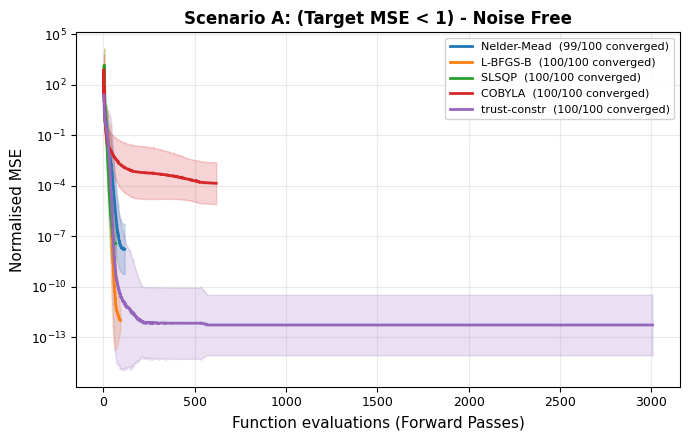

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            4.1996e-10     0.9360     1.1792
  L-BFGS-B               4.0367e-15     0.7469     0.5819
  SLSQP                  2.6862e-11     0.2875     0.2752
  COBYLA                 6.4030e-07     0.7467     0.5817
  trust-constr           1.7658e-16     0.7469     0.5819

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: trust-constr,  MSE=1.7658e-16
    I=0.74691 A,  I2=0.58186 A


In [15]:
noise = False
sigma = None
results_A, df_A, final_summary = run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_VARS,A_BEAMLINE_LEN, METHODS_A, scale="log",METHOD_OPTIONS=METHOD_OPTIONS, use_log=use_log, use_epsilon=log_epsilon, noise=noise, sigma=sigma)
display_results(results_A, REF_I)
mse_without_noise={}
for m, _ in METHODS_A:
    mse_without_noise[m]=results_A[m][0]["final_mse"]

In [16]:
print(results_A)

{'Nelder-Mead': [{'run': 1, 'method': 'Nelder-Mead', 'scenario': 'A', 'final_mse': 2.6381005164907223e-09, 'nfev': 80, 'nit': 41, 'wall_time': 12.323, 'mse_curve': [np.float64(32.653221154223594), np.float64(52.627596250737255), np.float64(26.626634762345077), np.float64(14.848062706835739), np.float64(6.573792238459152), np.float64(5.447605203062962), np.float64(2.5719370086315925), np.float64(1.9510048359314596), np.float64(1.93192390221797), np.float64(0.8465586439345228), np.float64(20.82762497032696), np.float64(32.71526794689717), np.float64(2.3501035619827273), np.float64(3.4082986983024037), np.float64(2.163344895475324), np.float64(1.0168570600385292), np.float64(4.325857522400524), np.float64(1.3169016401646298), np.float64(1.494506253277536), np.float64(1.0339090476704174), np.float64(0.9955593556352834), np.float64(0.6890885852187365), np.float64(0.5792522638861982), np.float64(0.9280758874330112), np.float64(0.7789097362588923), np.float64(0.5020187346912021), np.float64(0

use_log: False
use noise: True
noise standard deviation: 1e-08

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=2.628e-09  nit=41  nfev=80   t=13.03s
  Nelder-Mead             run 2/100  MSE=6.128e-09  nit=41  nfev=78   t=12.59s
  Nelder-Mead             run 3/100  MSE=2.301e-09  nit=50  nfev=97   t=17.36s
  Nelder-Mead             run 4/100  MSE=4.372e-08  nit=28  nfev=55   t=9.99s
  Nelder-Mead             run 5/100  MSE=6.630e-09  nit=44  nfev=82   t=13.96s
  Nelder-Mead             run 6/100  MSE=3.856e-08  nit=31  nfev=61   t=9.98s
  Nelder-Mead             run 7/100  MSE=4.303e-08  nit=44  nfev=84   t=17.16s
  Nelder-Mead             run 8/100  MSE=4.362e-09  nit=50  nfev=96   t=17.21s
  Nelder-Mead             run 9/100  MSE=1.184e-08  nit=49  nfev=92   t=16.42s
  Nelder-Mead             run 10/100  MSE=3.065e-09  nit=49  nfev=91   t=15.59s
  Nelder-Mead             run 11/100  MSE=6.615e-09  nit=38  nfev=75   t=12.43s
  Nelder-Mead             ru

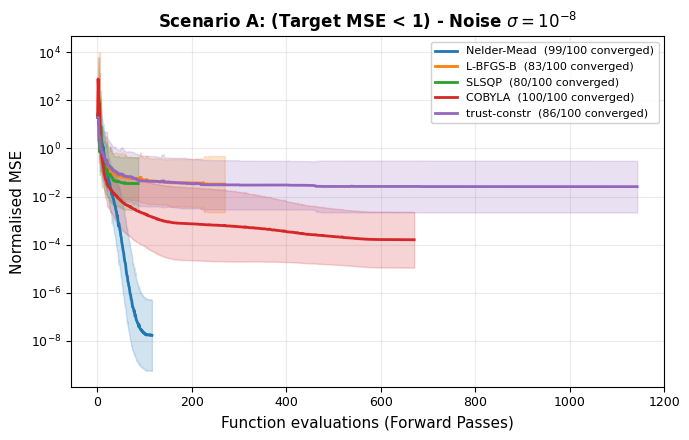

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            4.1937e-10     0.9360     1.1792
  L-BFGS-B               5.8141e-08     0.7470     0.5819
  SLSQP                  2.3605e-05     0.7456     0.5811
  COBYLA                 4.6206e-07     0.7467     0.5817
  trust-constr           8.3158e-06     0.7461     0.5813

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=4.1937e-10
    I=0.93599 A,  I2=1.17920 A
use_log: False
use noise: True
noise standard deviation: 1e-06

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=3.569e-09  nit=41  nfev=80   t=15.72s
  Nelder-Mead             run 2/100  MSE=4.406e-09  nit=41  nfev=78   t=14.58s
  Nelder-Mead             run 3/100  MSE=1.654e-09  nit=50  nfev=97   t=17.71s
  Nelder-Mead   

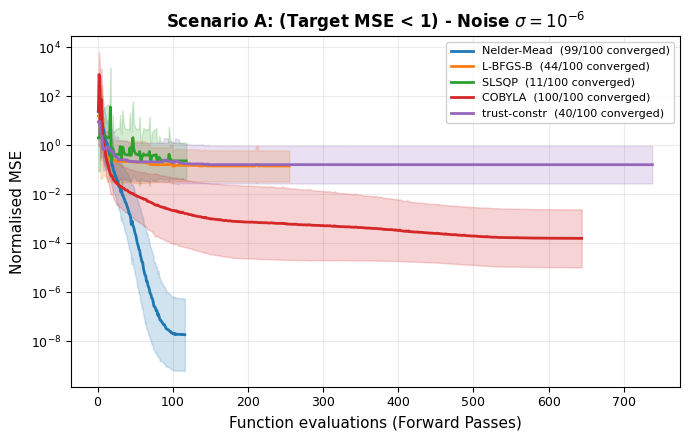

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            4.2900e-10     0.8715     1.1436
  L-BFGS-B               1.2400e-03     0.9208     1.1685
  SLSQP                  2.0144e-03     0.8512     1.1292
  COBYLA                 6.8075e-08     0.7470     0.5819
  trust-constr           9.6580e-05     0.8643     1.1397

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=4.2900e-10
    I=0.87154 A,  I2=1.14360 A
use_log: False
use noise: True
noise standard deviation: 0.0001

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=3.889e-08  nit=42  nfev=85   t=13.69s
  Nelder-Mead             run 2/100  MSE=3.845e-07  nit=40  nfev=83   t=13.35s
  Nelder-Mead             run 3/100  MSE=2.988e-09  nit=50  nfev=106  t=17.33s
  Nelder-Mead  

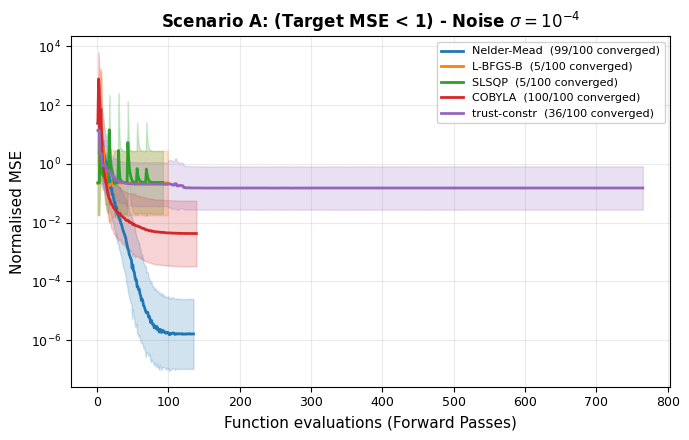

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            4.2132e-10     0.7468     0.5818
  L-BFGS-B               1.4601e-03     0.8519     1.1302
  SLSQP                  1.7194e-03     0.8504     1.1292
  COBYLA                 9.8262e-08     0.7470     0.5819
  trust-constr           1.2055e-03     0.8501     1.1301

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=4.2132e-10
    I=0.74681 A,  I2=0.58176 A
use_log: False
use noise: True
noise standard deviation: 0.01

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=1.197e-02  nit=149 nfev=400  t=64.23s
  Nelder-Mead             run 2/100  MSE=4.102e-05  nit=159 nfev=400  t=64.70s
  Nelder-Mead             run 3/100  MSE=1.126e+01  nit=158 nfev=400  t=64.82s
  Nelder-Mead    

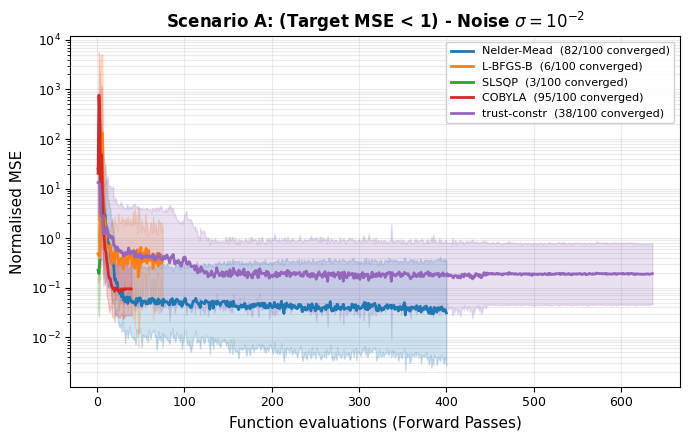

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            1.0065e-06     0.2910     0.2729
  L-BFGS-B               4.8804e-02     0.8519     1.1302
  SLSQP                  1.7266e-02     0.8519     1.1302
  COBYLA                 1.0290e-04     0.8778     1.1447
  trust-constr           3.1952e-03     0.2685     0.2582

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=1.0065e-06
    I=0.29103 A,  I2=0.27286 A
use_log: False
use noise: True
noise standard deviation: 1.0

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=5.237e-03  nit=160 nfev=400  t=64.74s
  Nelder-Mead             run 2/100  MSE=3.012e-03  nit=145 nfev=400  t=65.07s
  Nelder-Mead             run 3/100  MSE=2.622e-02  nit=143 nfev=400  t=65.33s
  Nelder-Mead     

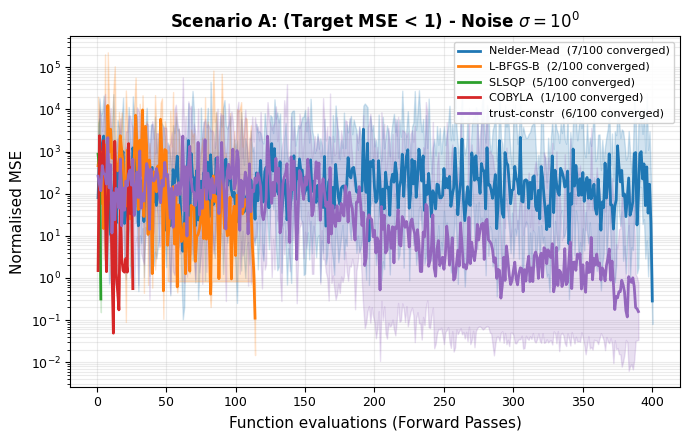

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            1.4139e-05     1.3153     0.1247
  L-BFGS-B               5.3505e-01     1.2165     0.0641
  SLSQP                  4.6357e-02     0.0936     0.9121
  COBYLA                 1.4406e-03     1.1369     0.0173
  trust-constr           1.6454e-03     1.4000     1.0861

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=1.4139e-05
    I=1.31534 A,  I2=0.12469 A


In [17]:
mse_with_noise = {}
for m, _ in METHODS_A:
    mse_with_noise[m] = []

noise = True
sigma_set = [1e-8, 1e-6, 1e-4, 1e-2, 1]
for sigma in sigma_set:
    sigma = sigma * torch.ones(26)
    results_A, df_A, final_summary = run_scenario_A(
        CURRENT_BOUNDS,
        EPSILON,
        N_RUNS_A,
        REF_I,
        A_OBJ,
        A_VARS,
        A_BEAMLINE_LEN,
        METHODS_A,
        scale="log",
        METHOD_OPTIONS=METHOD_OPTIONS,
        use_log=use_log,
        use_epsilon=log_epsilon,
        noise=noise,
        sigma=sigma,
    )
    display_results(results_A, REF_I)
    for m, _ in METHODS_A:
        mse_with_noise[m].append((results_A[m][0]["final_mse"], sigma))

give the plot of mse difference vs sigma for each method

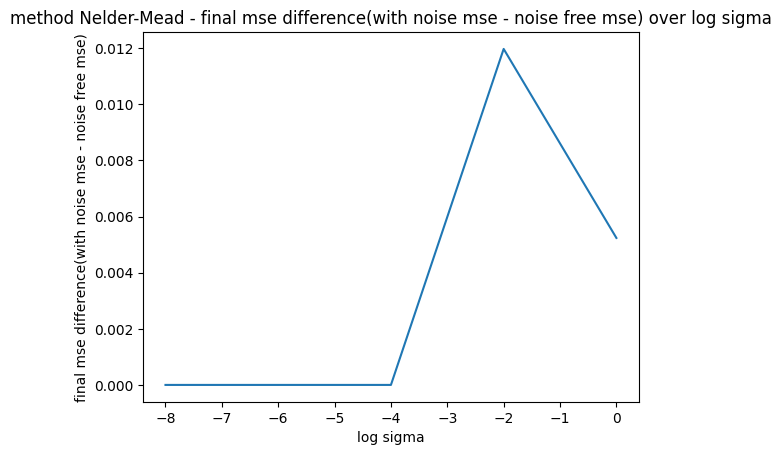

C:\Users\yilu2\AppData\Local\Temp\ipykernel_30992\4226982226.py:9: RuntimeWarning: overflow encountered in exp
  exp_mse_diff=np.exp(mse_diff)


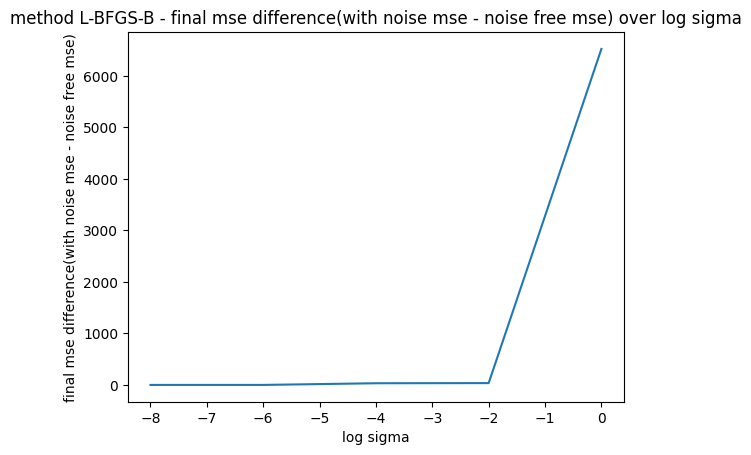

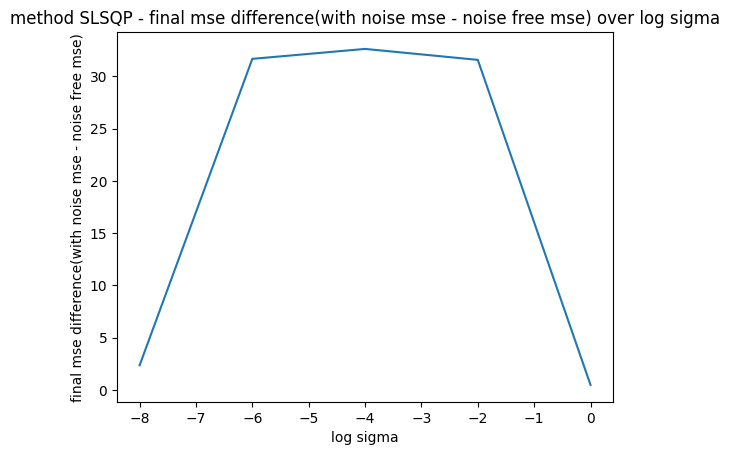

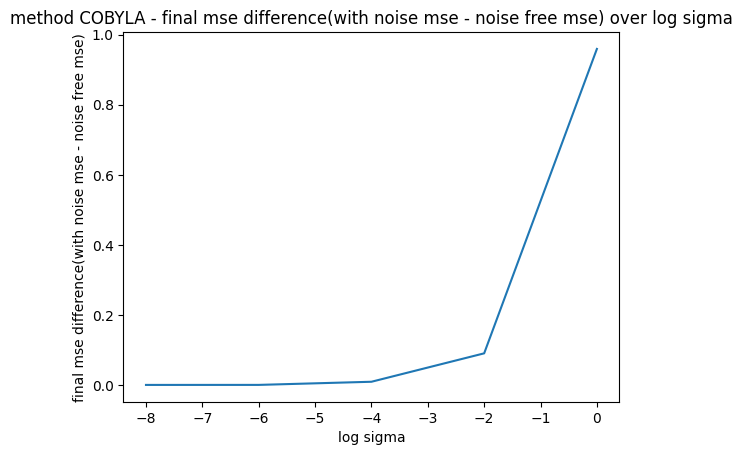

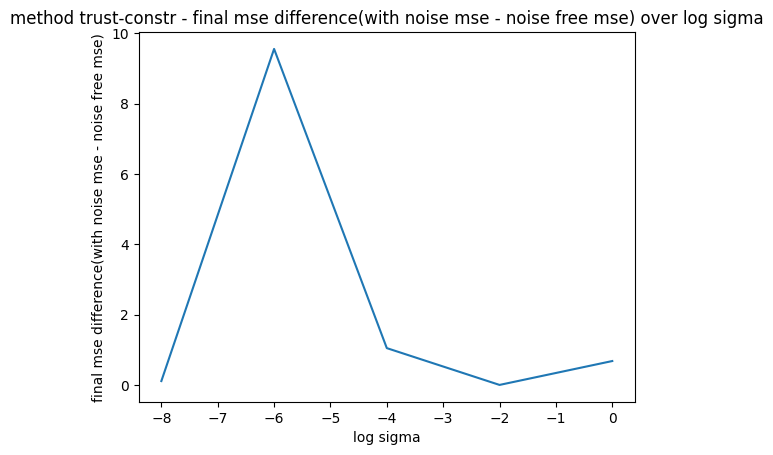

In [18]:
import matplotlib.pyplot as plt

log_sig=np.array([-8,-6, -4, -2, 0])


for m, _ in METHODS_A:

    mse_diff=np.array([i[0]-mse_without_noise[m] for i in mse_with_noise[m]])
    exp_mse_diff=np.exp(mse_diff)
    plt.plot(log_sig, mse_diff)
    plt.xlabel("log sigma")
    plt.ylabel("final mse difference(with noise mse - noise free mse)")
    plt.title(f"method {m} - final mse difference(with noise mse - noise free mse) over log sigma")
    plt.show()